# Titanic: Machine Learning from Disaster

Bài thực hành xây dựng **mạng MLP đơn giản bằng PyTorch** để dự đoán hành khách sống sót trên Titanic.

Quy trình được trình bày:

1. Load Data
2. Data Analysis
3. Data Preprocessing
4. Define Model
5. Fit Model
6. Model Evaluation
7. Tinh chỉnh tham số đơn giản
8. Prediction
9. Submission

## 1. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

import wandb

print("PyTorch:", torch.__version__)

PyTorch: 2.6.0


## 2. Load Data

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Số hành khách trong train: ", len(train))
print("Số hành khách trong test: ", len(test))

train.head()

Số hành khách trong train:  891
Số hành khách trong test:  418


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Data Analysis

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
print("Thống kê mô tả")
print(train.describe())

Thống kê mô tả
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [5]:
print("Giá trị bị thiếu trong train:")
print(train.isnull().sum())

Giá trị bị thiếu trong train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


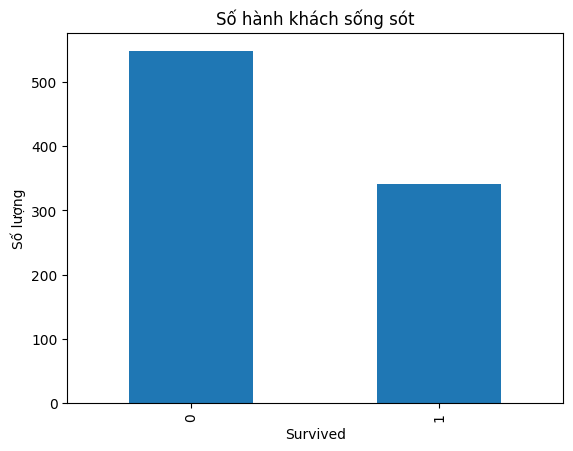

In [6]:
# Phân phối của biến mục tiêu
# Số khách hàng sống sót / không sống sót
train["Survived"].value_counts().sort_index().plot(kind="bar")
plt.title("Số hành khách sống sót")
plt.xlabel("Survived")
plt.ylabel("Số lượng")
plt.show()

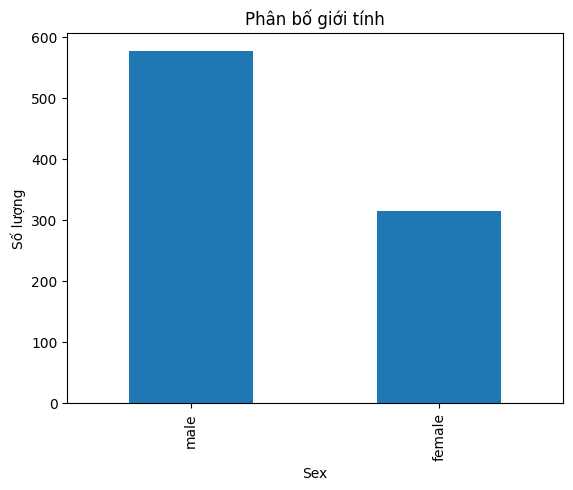

In [7]:
# Số lượng hành khách theo giới tính (Nam/ Nữ)
train["Sex"].value_counts().plot(kind="bar")
plt.title("Phân bố giới tính")
plt.xlabel("Sex")
plt.ylabel("Số lượng")
plt.show()

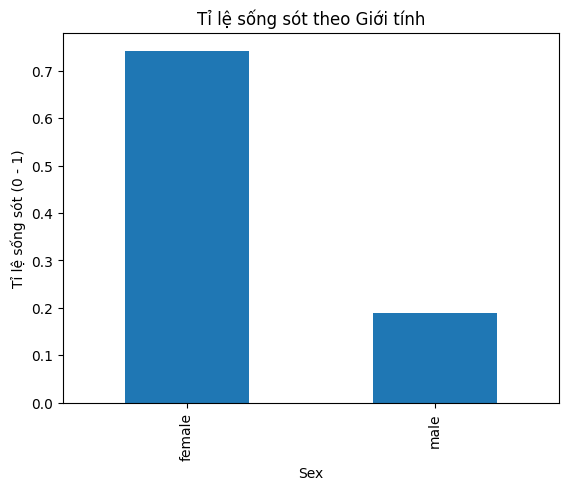

In [8]:
# Tỉ lệ sống sót theo Giới tính (Tính trung bình)
train.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.title("Tỉ lệ sống sót theo Giới tính")
plt.xlabel("Sex")
plt.ylabel("Tỉ lệ sống sót (0 - 1)")
plt.show()

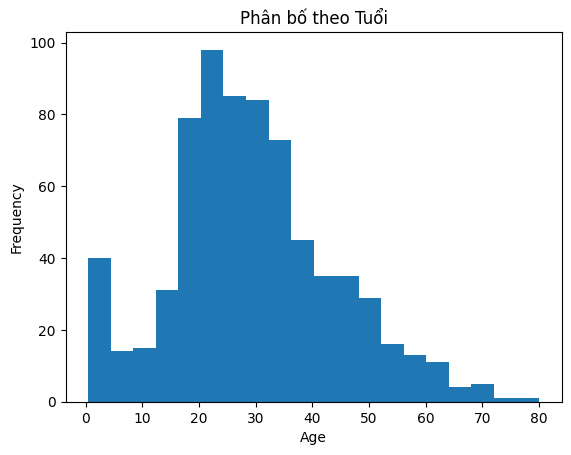

In [9]:
# Phân bố theo Tuổi
train["Age"].plot(kind="hist", bins=20)
plt.title("Phân bố theo Tuổi")
plt.xlabel("Age")
plt.show()

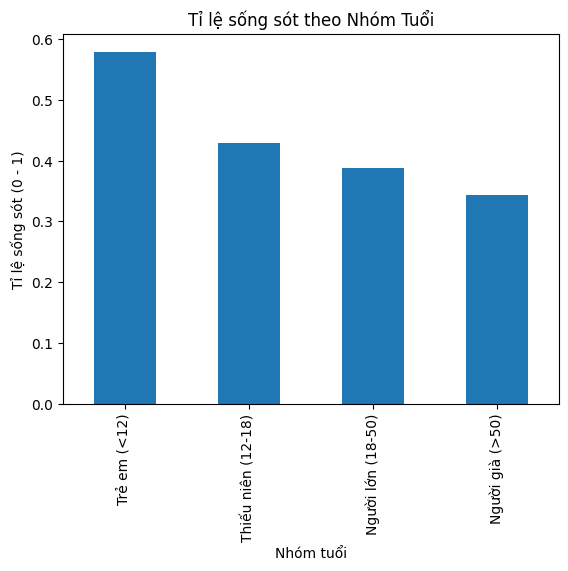

In [10]:
# Tỉ lệ sống sót theo nhóm tuổi
bins = [0, 12, 18, 50, 100]
labels = ['Trẻ em (<12)', 'Thiếu niên (12-18)', 'Người lớn (18-50)', 'Người già (>50)']

train["AgeGroup"] = pd.cut(train["Age"], bins=bins, labels=labels)
train.groupby("AgeGroup", observed=False)["Survived"].mean().plot(kind="bar")
plt.title("Tỉ lệ sống sót theo Nhóm Tuổi")
plt.xlabel("Nhóm tuổi")
plt.ylabel("Tỉ lệ sống sót (0 - 1)")
plt.show()

**Lí do chọn biến "Sex" và "Age"**  
Nhóm ưu tiên đặc biệt: Nguyên tắc cứu hộ ưu tiên "Phụ nữ và Trẻ em trước". Nhìn vào tỉ lệ sống sót theo Giới tính và Nhóm tuổi thì thấy rõ ràng:  
   - Tỉ lệ sống sót của Nữ (khoảng 74.2%) cao hơn Nam (khoảng 18.9%) rất nhiều
   - Nhóm tuổi Trẻ em có tỉ lệ sống sót cao nhất (khoảng 57-58%)

## 4. Data Preprocessing
Để giữ bài đơn giản giống tài liệu PDF, ta sử dụng các thuộc tính:

- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Fare`
- `Embarked`

Các bước:

- Điền tuổi thiếu bằng tuổi trung bình.
- Điền Fare thiếu bằng giá vé trung bình.
- One-hot encoding cho `Sex`, `Embarked`, `Pclass`.
- Chuẩn hóa các biến số.

In [11]:
for df in [train, test]: 
    # 1. Điền dữ liệu bị thiếu
    df["Age"] = df["Age"].fillna(df["Age"].mean())
    df["Fare"] = df["Fare"].fillna(df["Fare"].mean())
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
    
    # 2.One-hot encoding
    sex = pd.get_dummies(df["Sex"], prefix="Sex", drop_first="True")
    embark = pd.get_dummies(df["Embarked"], prefix="Embarked", drop_first="True")
    pclass = pd.get_dummies(df["Pclass"], prefix="Pclass", drop_first="True")
    
    df_encoded = pd.concat([df, sex, embark, pclass], axis=1)
    
    # Bỏ các cột không sử dụng
    df_encoded.drop(
        ["Pclass", "Sex", "Embarked", "Cabin", "PassengerId", "Name", "Ticket", "AgeGroup"],
        axis=1,
        inplace=True,
        errors="ignore"
    )
    
    if 'Survived' in df.columns:
        train_p = df_encoded
    else:
        test_p = df_encoded
        
train_p.head()

,Survived,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,22.0,1,0,7.2500,True,False,True,False,True
1,1,38.0,1,0,71.2833,False,False,False,False,False
2,1,26.0,0,0,7.9250,False,False,True,False,True
3,1,35.0,1,0,53.1000,False,False,True,False,False
4,0,35.0,0,0,8.0500,True,False,True,False,True


### Đồng bộ giữa cột Train và Test

**Vấn đề:** Khi One_Hot Encoding (get_dummies), tập Train có thể tạo ra những cột biến phân loại mà tập Test không có (Ví dụ: Một giá trị hiếm ở cột Embarked chỉ xuất hiện ở tập Train)  

**Giải pháp:** X.align lấy khung danh sách 9 cột của tập Train làm chuẩn (join="left"). Nếu tập Test bị thiếu cột nào sao với Train, nó sẽ tự dộng thêm cột đó vào và điền giá trị bằng 0 (fill_value=0)

**Mục đích:** Đảm bảo cả hai tập có đúng 9 cột theo đúng thứ tự, tránh lỗi lệch kích thước (mismatch dimesion) khi đưa dữ liệu vào mô hình

In [12]:
X = train_p.drop("Survived", axis=1)
y = train_p["Survived"]

X_test_kaggle = test_p.copy()

X, X_test_kaggle = X.align(
    X_test_kaggle,
    join="left",
    axis=1,
    fill_value=0
)

print("Các cột đầu vào:")
print(X.columns.tolist())

Các cột đầu vào:
['Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Pclass_2', 'Pclass_3']


### Chia tập Train/ Validation & Chuẩn hóa

**stratify=y:** Đảm bảo tỉ lệ người sống sót / người chết ở trập Train (70%) và tập Val (30%) là hoàn toàn bằng nhau (tránh trường hợp dồn hết người sống vào một tập)  

**fit_transform vs transform:scaler.fit_transform(X_train):** 
- Tính ra trung bình ($\mu$) và độ lệch chuẩn ($\sigma$) của tập Train, sau đó chuẩn hóa tập Train về dạng có trung bình = 0 và độ lệch chuẩn = 1.
- scaler.transform(X_val) / transform(X_test_kaggle): Dùng lại đúng $\mu$ và $\sigma$ đã tính từ tập Train để chuẩn háo tập Val và Test (nhằm tránh rò rỉ thông tin)

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=1,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test_kaggle_scaled = scaler.transform(X_test_kaggle)

print("Kích thước tập Train và Val: ", X_train.shape, X_val.shape)

Kích thước tập Train và Val:  (623, 9) (268, 9)


### Chuyển sang Tensor

**dtype=torch.float32:** PyTorch yêu cầu dữ liệu đầu vào mô hình MLP phải ở dạng số thực 32-bit (float32)  

**.view(-1, 1):** Chuyển nhãn y từ mảng 1 chiều [623] thành mảng 2 chiều cột đứng [623, 1]. Việc này bắt buộc để kích thước đầu ra mô hình (N, 1) khớp chính xác với kích thước của nhãn thực tế khi tính hàm mất mát (Loss Function)

**DataLoader(..., batch_size=32, shuffle=True):** Chia 623 mẫu dữ liệu thành từng nhóm nhỏ (mỗi nhóm 32 mẫu) và xáo trộn vị trí (shuffle=True) giúp mạng nơ-ron học ổn định hơn qua từng chu kỳ

In [14]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_kaggle_t = torch.tensor(X_test_kaggle_scaled, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32,
    shuffle=True
)

print("Shape Tensor đầu vào: ", X_train_t.shape, y_train_t.shape)

Shape Tensor đầu vào:  torch.Size([623, 9]) torch.Size([623, 1])


## 5. Define Model

### 1. Số nút đầu vào (Input Size = 9)

Số nút đầu vào bắt buộc phải khớp 100% với số đặc trưng (columns) của dữ liệu sau khi chuẩn hóa. Vì ở bước Preprocessing, dữ liệu `X_train` sau khi One-Hot Encoding và align có đúng **9 cột** (`Age`, `Fare`, `Sex_male`, `Pclass_2`, `Pclass_3`, `Embarked_Q`, `Embarked_S`, `SibSp`, `Parch`), nên `input_size` bắt buộc phải là **9**.

### 2. Số nút đầu ra (Output Size = 1)

Bài toán Titanic là **phân loại nhị phân** (Binary Classification) – dự đoán xem hành khách sống (`1`) hay chết (`0`).

* Với bài toán này, lớp cuối cùng chỉ cần **1 nút duy nhất** để trả về một điểm số đại diện cho xác suất sống sót.

### 3. Cấu trúc các lớp ẩn (Hidden Layers: 32 → 16)

Việc chọn 2 lớp ẩn với số nút **32** và **16** tuân theo các quy tắc thực nghiệm (Heuristics) phổ biến:

* **Mô hình hình phễu (Thu nhỏ dần):** Giảm dần kích thước từ $9 \rightarrow 32 \rightarrow 16 \rightarrow 1$ giúp mô hình nén thông tin từ các đặc trưng thô thành các đặc trưng trừu tượng cốt lõi trước khi đưa ra quyết định cuối cùng.
* **Quy mô dữ liệu nhỏ:** Tập dữ liệu Titanic chỉ có hơn 800 dòng. Nếu dựng mạng quá sâu (ví dụ 4–5 lớp) hoặc quá rộng (128, 256 nút), mô hình sẽ rất dễ bị **Overfitting**. Mạng 2 lớp ẩn với 32 và 16 nút là kích thước vừa đủ.
* **Hàm kích hoạt `ReLU`:** Được chọn vì tính đơn giản, giúp tính toán đạo hàm nhanh và tránh hiện tượng triệt tiêu đạo hàm (Vanishing Gradient) so với hàm `Sigmoid` hay `Tanh` ở các lớp ẩn.

### Tóm tắt luồng thiết kế

$$\text{Data (9 cột)} \xrightarrow{\text{Linear}(9 \rightarrow 32)} \text{Trích xuất đặc trưng} \xrightarrow{\text{ReLU}} \xrightarrow{\text{Linear}(32 \rightarrow 16)} \text{Nén đặc trưng} \xrightarrow{\text{ReLU}} \xrightarrow{\text{Linear}(16 \rightarrow 1)} \text{Ra điểm số}$$

In [17]:
class TitanicMLP(nn.Module):
    def __init__(self, input_size, hidden1=32, hidden2=16):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            
            nn.Linear(hidden2, 1),
        )
        
    def forward(self, x):
        return self.net(x)
    
model = TitanicMLP(X_train.shape[1])

print(model)

TitanicMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 6. Fit Model

Dùng:

- Loss: `BCEWithLogitsLoss`
- Optimizer: `Adam`
- Epoch: `100`

W&B chỉ được dùng để theo dõi `loss` và `accuracy` cho đơn giản.

In [16]:
WANDB_MODE = "disabled"

run = wandb.init(
    project="titanic-pytorch",
    config={
        "hidden1":32,
        "hidden2":16,
        "learning_rate":0.001,
        "batch_size":32,
        "epochs":100
    },
    mode=WANDB_MODE
)

In [20]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    model.eval()
    
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_probs = torch.sigmoid(val_logits)
        val_pred = (val_probs >= 0.5).int().numpy().ravel()
        
    val_acc = accuracy_score(y_val, val_pred)
    avg_loss = total_loss / len(train_loader)
    
    wandb.log({
        "epoch":epoch + 1,
        "train_loss": avg_loss,
        "val_accuracy": val_acc
    })
    
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d}/{epochs} - "
            f"Loss: {avg_loss:.4f} - "
            f"Val Acc: {val_acc:.4f}"
        )
wandb.finish()

Epoch  10/100 - Loss: 0.3143 - Val Acc: 0.8134
Epoch  20/100 - Loss: 0.3145 - Val Acc: 0.8060
Epoch  30/100 - Loss: 0.3123 - Val Acc: 0.8060
Epoch  40/100 - Loss: 0.2986 - Val Acc: 0.8022
Epoch  50/100 - Loss: 0.3201 - Val Acc: 0.8097
Epoch  60/100 - Loss: 0.2937 - Val Acc: 0.7985
Epoch  70/100 - Loss: 0.2955 - Val Acc: 0.8022
Epoch  80/100 - Loss: 0.2875 - Val Acc: 0.7948
Epoch  90/100 - Loss: 0.2873 - Val Acc: 0.8022
Epoch 100/100 - Loss: 0.2892 - Val Acc: 0.7910


- **criterion = nn.BCEWithLogitsLoss():** Hàm mất mát chuyên dụng cho phân loại nhị phân (0/1).

- **loss.backward() & optimizer.step():** Đây là quá trình Backpropagation (lan truyền ngược). backward() tính độ lệch giữa dự đoán và thực tế, còn step() điều chỉnh lại các trọng số trong mạng nơ-ron để giảm thiểu độ sai lệch đó ở lượt sau.

- **torch.sigmoid(...) >= 0.5:** Chuyển đổi điểm số thô (Logit) ra xác suất từ 0 đến 1. Nếu xác suất $\ge 0.5$ ($50\%$), mô hình sẽ phân loại là sống (1), ngược lại là chết (0).

## 7. Model Evalation

In [21]:
model.eval()

with torch.no_grad():
    logits = model(X_val_t)
    probs = torch.sigmoid(logits)
    predictions = (probs >= 0.5).int().numpy().ravel()

print(classification_report(y_val, predictions))

              precision    recall  f1-score   support

           0       0.81      0.86      0.84       165
           1       0.75      0.68      0.71       103

    accuracy                           0.79       268
   macro avg       0.78      0.77      0.77       268
weighted avg       0.79      0.79      0.79       268



**Nhóm 0 (Hành khách thiệt mạng):**
- Precision = 0.81 (81%): Trong tất cả các trường hợp mô hình phán đoán là "Chết", có 81% trường hợp đoán chính xác.

- Recall = 0.86 (86%): Trong tổng số 165 người thực tế bị thiệt mạng, mô hình phát hiện ra được 86% (142/165 người).

- F1-score = 0.84: Trung bình hài hòa giữa Precision và Recall của nhãn 0, cho thấy mô hình nhận diện nhóm người chết rất tốt.

**Nhóm 1 (Hành khách sống sót):**
- Precision = 0.75 (75%): Trong tất cả các trường hợp mô hình phán đoán là "Sống", chỉ có 75% đoán đúng (vì dính 23 trường hợp đoán nhầm ở FP).

- Recall = 0.68 (68%): Trong tổng số 103 người thực tế sống sót, mô hình chỉ tìm ra được 68% (70/103 người), bỏ sót 33 người (FN).

- F1-score = 0.71: Thấp hơn nhãn 0, phản ánh việc mô hình vẫn bị khó khăn hơn khi dự đoán các trường hợp sống sót.

In [24]:
print("Confusion Matrix:")
print(confusion_matrix(y_val, predictions))

print("\nAccuracy:")
print(accuracy_score(y_val, predictions))

Confusion Matrix:
[[142  23]
 [ 33  70]]

Accuracy:
0.7910447761194029


**Confusion Matrix**
- TN = 142 (True Negative): Mô hình đoán Chết và thực tế họ Chết (Đoán đúng).

- FP = 23 (False Positive): Mô hình đoán Sống nhưng thực tế họ Chết (Đoán sai - Báo động giả).

- FN = 33 (False Negative): Mô hình đoán Chết nhưng thực tế họ Sống (Đoán sai - Bỏ sót).

- TP = 70 (True Positive): Mô hình đoán Sống và thực tế họ Sống (Đoán đúng).

**Accuracy**
- Accuracy = 0.7910 (79.10%):

- Tổng số ca đoán đúng trên toàn tập Validation:
$$\frac{142 + 70}{268} = \frac{212}{268} \approx 79.10\%$$

- Macro Avg = 0.78 (78%): Trung bình cộng đơn thuần chỉ số của 2 nhóm (không tính đến số lượng mẫu của từng nhóm).

- Weighted Avg = 0.79 (79%): Trung bình có trọng số theo số lượng mẫu (165 mẫu nhãn 0 và 103 mẫu nhãn 1).

## 8. Tinh chỉnh tham số mạng đơn giản

Ta thử **3 cấu hình** khác nhau thay vì dùng Grid Search phức tạp.

Các tham số được thử:

- `hidden1`
- `hidden2`
- `learning_rate`

Mục tiêu: chọn cấu hình có Accuracy trên validation cao nhất.

In [28]:
configs = [
    {"hidden1": 16, "hidden2": 8,  "lr": 0.001},
    {"hidden1": 32, "hidden2": 16, "lr": 0.001},
    {"hidden1": 64, "hidden2": 32, "lr": 0.001}
]

results = []

for cfg in configs:

    m = TitanicMLP(
        input_size=X_train.shape[1],
        hidden1=cfg["hidden1"],
        hidden2=cfg["hidden2"]
    )

    optimizer = torch.optim.Adam(m.parameters(), lr=cfg["lr"])
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(50):
        m.train()

        for xb, yb in train_loader:
            optimizer.zero_grad()

            logits = m(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

    m.eval()

    with torch.no_grad():
        pred = (
            torch.sigmoid(m(X_val_t)) >= 0.5
        ).int().numpy().ravel()

    acc = accuracy_score(y_val, pred)

    results.append({
        "hidden1": cfg["hidden1"],
        "hidden2": cfg["hidden2"],
        "lr": cfg["lr"],
        "accuracy": acc,
        "model": m
    })

result_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "model"}
    for r in results
])

result_df

,hidden1,hidden2,lr,accuracy
0,16,8,0.001,0.828358
1,32,16,0.001,0.813433
2,64,32,0.001,0.828358


**Config 1:** Mạng hơi nhỏ, chưa học hết các mối quan hệ phức tạp.

**Config 2:** Cấu hình tối ưu nhất (Cân bằng hoàn hảo giữa sức học và khả năng tổng quát hóa).

**Config 3:** Mạng quá lớn, có dấu hiệu Overfitting nhẹ khiến Accuracy giảm lại.

In [29]:
best_result = max(results, key=lambda x: x["accuracy"])

best_model = best_result["model"]

print("Cấu hình tốt nhất:")
print("hidden1 =", best_result["hidden1"])
print("hidden2 =", best_result["hidden2"])
print("lr      =", best_result["lr"])
print("accuracy=", best_result["accuracy"])

Cấu hình tốt nhất:
hidden1 = 16
hidden2 = 8
lr      = 0.001
accuracy= 0.8283582089552238


## 9. Prediction cho tập test Kaggle

Tập `test.csv` không có nhãn `Survived`.

Ta dùng `best_model` để dự đoán cho toàn bộ 418 hành khách trong tập test.

In [30]:
best_model.eval()

with torch.no_grad():
    test_logits = best_model(X_kaggle_t)

    test_probabilities = torch.sigmoid(test_logits)

    test_predictions = (
        test_probabilities >= 0.5
    ).int().numpy().ravel()

print(test_predictions[:20])
print("Số dự đoán:", len(test_predictions))

[0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1]
Số dự đoán: 418


## 10. Submission

File submission cần có đúng 2 cột:

- `PassengerId`
- `Survived`

Ta lấy `PassengerId` trực tiếp từ `test.csv` và dùng kết quả dự đoán của PyTorch.

In [31]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [32]:
submission.to_csv("submission_pytorch.csv", index=False)

print("Đã tạo file: submission_pytorch.csv")
print("Kích thước:", submission.shape)

Đã tạo file: submission_pytorch.csv
Kích thước: (418, 2)


### Kiểm tra file submission

In [33]:
check_submission = pd.read_csv("submission_pytorch.csv")

print(check_submission.head())
print()
print(check_submission.info())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB
None


## 11. Kết luận

Quy trình PyTorch trong bài:

**Load Data → Data Analysis → Data Preprocessing → Define Model → Fit Model → Model Evaluation → Tuning → Prediction → Submission**

Điểm khác so với Logistic Regression trong tài liệu mẫu là:

- Mô hình được xây dựng bằng `torch.nn.Module`.
- Huấn luyện bằng vòng lặp PyTorch.
- Dùng `BCEWithLogitsLoss`.
- Dùng `Adam`.
- Dự đoán xác suất bằng `torch.sigmoid`.
- Kết quả cuối cùng được lưu vào `submission_pytorch.csv` để nộp Kaggle.